# Perturbation LOO Evaluation

Evaluates the perturbation model on a held-out cell type in the CRC region.
For each cell type we compute the top-100 pseudobulk logFC genes (CRC vs REF),
perturb REF cells' spatial context accordingly, and measure how well the
predicted expression shift matches the real CRC expression.

In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

import sys

import numpy as np
import pandas as pd
import scanpy as sc
import decoupler as dc
import matplotlib.pyplot as plt

from src import cellina_graph
from cellina_graph import CellinaModel, make_perturbed_expression
from cellina_graph._spatial_utils import spatial_neighbors

from perturb_utils import load_crc_slide, split_indices, compute_cf_logfc

plt.rcParams['figure.dpi'] = 75
print(cellina_graph.__version__)

0.0.9


In [2]:
# ── Config ──────────────────────────────────────────────────────────────────
slide_id         = 242
labels_key       = 'coarse_type'
domains_key      = 'typ'
holdout_celltype = 'T_cell'
holdout_domains  = ('CRC', 'TVA')   # hold out from all matching regions (substring match)
top_n_perturb    = 100   # genes used to perturb spatial context
top_n            = 50   # genes used to evaluate metrics
min_cells        = 50    # minimum cells per domain per cell type to evaluate
batch_size       = 512
base_path        = 'results/perturb_loo'
save_path        = f'{base_path}/trained/crc_{slide_id}_{holdout_celltype}'
library_size     = 1e4


## 1. Data Loading

In [3]:
adata = load_crc_slide(slide_id, labels_key=labels_key, domains_key=domains_key)
print(adata)

AnnData object with n_obs × n_vars = 420694 × 3000
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_local_px', 'CenterY_local_px', 'Width', 'Height', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD68_CK8_18', 'Max.CD68_CK8_18', 'Mean.CD298_B2M', 'Max.CD298_B2M', 'Mean.CD45', 'Max.CD45', 'Mean.DAPI', 'Max.DAPI', 'cell_id', 'Dash', 'ISH.concentration', 'Panel', 'Run_Tissue_name', 'Run_name', 'assay_type', 'dualfiles', 'tissue', 'version', 'slide_ID', 'CenterX_global_px', 'CenterY_global_px', 'cell_ID', 'unassignedTranscripts', 'median_RNA', 'RNA_quantile_0.75', 'RNA_quantile_0.8', 'RNA_quantile_0.85', 'RNA_quantile_0.9', 'RNA_quantile_0.95', 'RNA_quantile_0.99', 'nCount_RNA', 'nFeature_RNA', 'median_negprobes', 'negprobes_quantile_0.75', 'negprobes_quantile_0.8', 'negprobes_quantile_0.85', 'negprobes_quantile_0.9', 'negprobes_quantile_0.95', 'negprobes_quantile_0.99', 'nCount_negprobes', 'nFeature_negprobes', 'median_falsecode', 'falsecode_quantile_0.75', 'falsecode_quantile_0.8', 'falsecode_quantile

## 2. Holdout Split

Mark `holdout_celltype` cells in CRC **and TVA** regions as test (holdout). These cells
are used **only for evaluation** — their ground-truth expression is the target we compare against.


In [4]:
train_idx, val_idx, test_idx = split_indices(
    adata,
    holdout_celltype=holdout_celltype,
    labels_key=labels_key,
    domains_key=domains_key,
    holdout_domains=holdout_domains,
)

print(f"train: {len(train_idx):,}  val: {len(val_idx):,}  test (holdout): {len(test_idx):,}")
print(f"Holdout cells: {adata.obs['is_holdout'].sum()} {holdout_celltype} in {holdout_domains}")
for dom in adata.obs.loc[adata.obs['is_holdout'], domains_key].unique():
    n = (adata.obs['is_holdout'] & (adata.obs[domains_key] == dom)).sum()
    print(f"  {dom}: {n}")


train: 366,630  val: 40,736  test (holdout): 13,328
Holdout cells: 13328 T_cell in ('CRC', 'TVA')
  242_CRC: 3245
  242_TVA: 10083


## 3. Spatial Graph & Features

In [5]:
spatial_neighbors(adata, bandwidth=100 / 0.12028, max_neighbours=50, standardize=False)

In [6]:
adata.obsm['spatial'][:,0].min(), adata.obsm['spatial'][:,0].max()

(3757, 109715)

In [7]:
adata.obsm['spatial'][:,1].min(), adata.obsm['spatial'][:,1].max()

(12159, 79040)

## 4. Model Training

In [8]:
CellinaModel.setup_anndata(
    adata,
    batch_key=None,
    labels_key=labels_key,
    domains_key=domains_key,
    layer='counts',
    spatial_connectivities_key='spatial_connectivities',
)

model = CellinaModel(
    adata,
    n_latent=20,
    convolution_type='gat',
    n_layers=3,
    classifier_lambda=1,
    discriminator_lambda=1,
    link_prediction_weight=0.1,
    spatial_loss_type='domain_clf', # or domain_clf
    condition_on_intrinsic=False,
)

/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting with edge prediction   


In [9]:
model.train(
    max_epochs=50,
    check_val_every_n_epoch=1,
    early_stopping=True,
    early_stopping_patience=5,
    early_stopping_monitor='vae_loss_validation',
    train_size=0.9,
    validation_size=0.1,
    plan_kwargs={
        'lr': 1e-3,
        'weight_decay': 0.0001,
        'normalize_losses': True,
    },
    datasplitter_kwargs={"external_indexing": [train_idx, val_idx, test_idx]},
    enable_checkpointing=True,
    batch_size=batch_size,
    devices=[1],
)

INFO: GPU available: True (cuda), used: True
2026-05-02 12:33:55 | [INFO] GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
2026-05-02 12:33:55 | [INFO] TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
2026-05-02 12:33:55 | [INFO] HPU available: False, using: 0 HPUs
INFO: You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
2026-05-02 12:33:55 | [INFO] You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.o

Training:   0%|          | 0/50 [00:00<?, ?it/s]

/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/lightning/pytorch/utilities/data.py:78: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 25255. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.
/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/lightning/pytorch/utilities/data.py:78: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 25080. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.
/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/lightning/pytorch/utilities/data.py:78: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 25403. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.
/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/lightning/pytorch/utilities/data.py

Monitored metric vae_loss_validation did not improve in the last 5 records. Best score: 602.498. Signaling Trainer to stop.


In [10]:
model.save(save_path, overwrite=True)

<Axes: xlabel='epoch'>

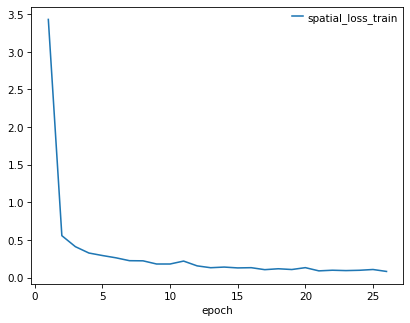

In [11]:
model.history_['spatial_loss_train'].plot()

<Axes: xlabel='epoch'>

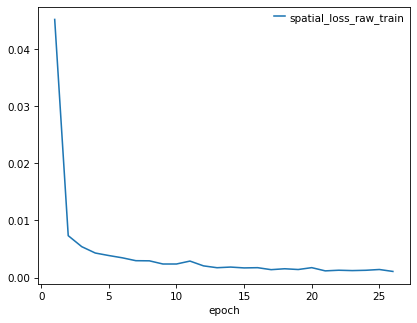

In [12]:
model.history_['spatial_loss_raw_train'].plot()

<Axes: xlabel='epoch'>

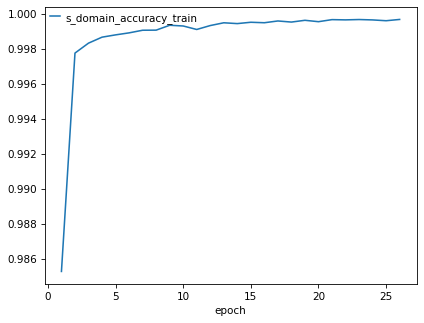

In [13]:
model.history_['s_domain_accuracy_train'].plot()

## Plot UMAP

In [14]:
adata.obsm['s'] = model.get_latent_representation(latent_key='s')

/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/scvi/dataloaders/_data_splitting.py:210: UserWarning: Last batch will have a small size of 1samples. Consider changing settings.batch_size or batch_size in model.traincurrently 128 to avoid errors during model training.
  self.n_train, self.n_val = validate_data_split(
/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: The usage of the 'directed' argument in 'NeighborSampler' is deprecated. Use `subgraph_type='induced'` instead.
  neighbor_sampler = NeighborSampler(


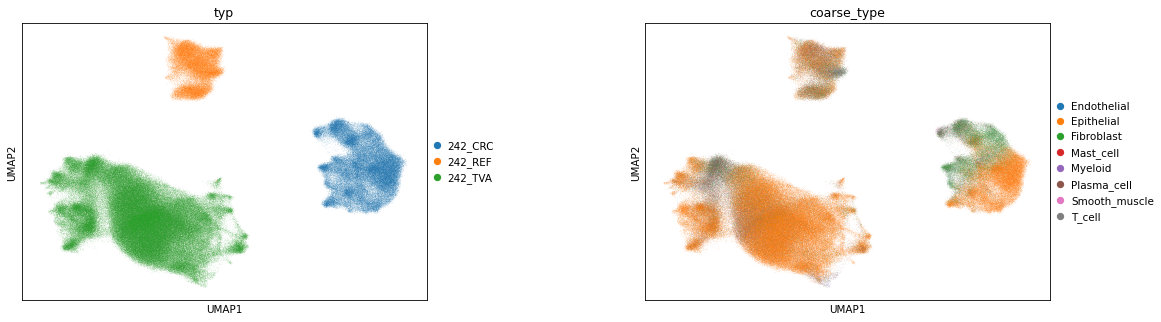

In [15]:
sc.pp.neighbors(adata, use_rep='s', n_neighbors=15)
sc.tl.umap(adata)
sc.pl.umap(adata, color=[domains_key, labels_key], wspace=0.4)

## 5. Counterfactual Neighbour Pool

In [16]:
# Infer domain labels
domains = [d for d in adata.obs[domains_key].astype(str).unique() if d != 'nan']
ref_label  = next(d for d in domains if 'REF' in d)
crc_label  = next(d for d in domains if 'CRC' in d)
tva_labels = [d for d in domains if 'TVA' in d]
target_labels = [crc_label] + tva_labels  # ordered list of disease domains

# Cell types present in REF and in at least one target domain
cell_types = [
    ct for ct in adata.obs[labels_key].cat.categories
    if ((adata.obs[domains_key] == ref_label) & (adata.obs[labels_key] == ct)).any()
    and any(
        ((adata.obs[domains_key] == tl) & (adata.obs[labels_key] == ct)).any()
        for tl in target_labels
    )
]

# Neighbour pool indices per target domain
target_pools = {
    tl: np.where(adata.obs[domains_key].astype(str) == tl)[0]
    for tl in target_labels
}

print(f"REF: {ref_label}")
print(f"Target domains: {target_labels}")
print(f"Cell types in REF + ≥1 target: {cell_types}")
for tl, idx in target_pools.items():
    print(f"  {tl} neighbour pool: {len(idx):,} cells")


REF: 242_REF
Target domains: ['242_CRC', '242_TVA']
Cell types in REF + ≥1 target: ['Endothelial', 'Epithelial', 'Fibroblast', 'Mast_cell', 'Myeloid', 'Plasma_cell', 'Smooth_muscle', 'T_cell']
  242_CRC neighbour pool: 89,908 cells
  242_TVA neighbour pool: 286,784 cells


In [17]:
# Pseudobulk logFC per target domain (used for node perturbation)
pdata = dc.pp.pseudobulk(
    adata=adata,
    sample_col=domains_key,
    groups_col=labels_key,
    mode='sum',
    layer='counts',
)
sc.pp.normalize_total(pdata, target_sum=1e4)
sc.pp.log1p(pdata)

def _shared_types(tl):
    return [
        ct for ct in pdata.obs[labels_key].unique()
        if ((pdata.obs[domains_key] == ref_label) & (pdata.obs[labels_key] == ct)).any()
        and ((pdata.obs[domains_key] == tl) & (pdata.obs[labels_key] == ct)).any()
    ]

def _compute_logfc_df(tl):
    cts = _shared_types(tl)
    return pd.concat([
        pd.Series(
            (
                pdata[(pdata.obs[domains_key] == tl) & (pdata.obs[labels_key] == ct)].X
                - pdata[(pdata.obs[domains_key] == ref_label) & (pdata.obs[labels_key] == ct)].X
            ).flatten(),
            index=pdata.var_names,
            name=ct,
        )
        for ct in cts
    ], axis=1).T

logfc_dfs = {tl: _compute_logfc_df(tl) for tl in target_labels}
for tl, df in logfc_dfs.items():
    print(f"{tl}: {df.shape}, types: {sorted(df.index.tolist())}")


242_CRC: (8, 3000), types: ['Endothelial', 'Epithelial', 'Fibroblast', 'Mast_cell', 'Myeloid', 'Plasma_cell', 'Smooth_muscle', 'T_cell']
242_TVA: (8, 3000), types: ['Endothelial', 'Epithelial', 'Fibroblast', 'Mast_cell', 'Myeloid', 'Plasma_cell', 'Smooth_muscle', 'T_cell']


In [18]:
# Build perturbed count layers — multiplicative shifts in count space
adata.X = adata.layers['counts'].copy()  # make_perturbed_expression reads adata.X

for tl in target_labels:
    target_short = next(k for k in ('CRC', 'TVA') if k in tl)
    logfc_series_dict = {
        ct: logfc_dfs[tl].loc[ct, logfc_dfs[tl].loc[ct].abs().nlargest(top_n_perturb).index]
        for ct in logfc_dfs[tl].index
    }
    make_perturbed_expression(
        adata,
        perturbations=logfc_series_dict,
        groupby=labels_key,
        layer_key=f'counts_cf_{target_short.lower()}',
        add_shift=False,   # multiplicative (not additive)
        base=np.e,
    )
    print(f"Stored adata.layers['counts_cf_{target_short.lower()}']")


Stored adata.layers['counts_cf_crc']
Stored adata.layers['counts_cf_tva']


## 6. Expression Retrieval & Metrics

For each cell type and each target domain (CRC, TVA), REF cells are given the target
domain's cells as counterfactual neighbours (graph edges are rewired). The model predicts
expression under this altered spatial context and we compare against real target expression.


In [19]:
rows = []
logfcs = {}
node_rows = []
node_logfcs = {}

def _normalize_total(arr, target_sum=library_size):
    return arr / arr.sum(axis=1, keepdims=True) * target_sum

for target_label in target_labels:
    target_all_idx = target_pools[target_label]
    target_short = next(k for k in ('CRC', 'TVA') if k in target_label)

    for ct in sorted(cell_types):
        ref_mask    = (adata.obs[labels_key] == ct) & (adata.obs[domains_key] == ref_label)
        target_mask = (adata.obs[labels_key] == ct) & (adata.obs[domains_key] == target_label)

        # For the holdout cell type, evaluate only on holdout cells
        if ct == holdout_celltype:
            target_mask = target_mask & adata.obs['is_holdout']

        ref_idx    = np.where(ref_mask.values)[0]
        target_idx = np.where(target_mask.values)[0]

        if len(ref_idx) < min_cells or len(target_idx) < min_cells:
            print(f"  skip {ct} ({target_short}): ref={len(ref_idx)}, target={len(target_idx)}")
            continue

        print(f"  {ct} ({target_short}): ref={len(ref_idx)}, target={len(target_idx)}")

        # Raw normalised expression
        ref_arr  = adata[ref_idx].layers['counts']
        ref_expr = ref_arr.toarray() if hasattr(ref_arr, 'toarray') else np.asarray(ref_arr)
        ref_expr = _normalize_total(ref_expr)


        # ref_expr = model.get_normalized_expression(
        #     indices=ref_idx,
        #     batch_size=batch_size,
        #     library_size=library_size,
        # )
        
        tgt_arr  = adata[target_idx].layers['counts']
        tgt_expr  = tgt_arr.toarray() if hasattr(tgt_arr, 'toarray') else np.asarray(tgt_arr)
        tgt_expr  = _normalize_total(tgt_expr)
        
        # tgt_expr = model.get_normalized_expression(
        #     indices=target_idx,
        #     batch_size=batch_size,
        #     library_size=library_size,
        # )

        # Counterfactual expression: rewire REF cells to use target-domain neighbours
        pert_expr = model.get_counterfactual_expression(
            indices=ref_idx,
            neighbour_indices=target_all_idx,
            batch_size=batch_size,
            n_neighbors_per_seed=50,
            library_size=library_size,
        )

        stats = compute_cf_logfc(
            ref_expr, pert_expr, tgt_expr,
            top_n=top_n,
            gene_names=adata.var_names.tolist(),
        )

        key = f"{ct}_{target_short}"
        rows.append(dict(
            cell_type=ct,
            target=target_short,
            holdout=(ct == holdout_celltype),
            n_ref=len(ref_idx),
            n_target=len(target_idx),
            pearson_r=stats['pearson_r'],
            spearman_r=stats['spearman_r'],
            precision=stats['precision'],
            mixing_index=stats['mixing_index'],
            edist=stats['edistance'],
        ))
        logfcs[key] = stats

        # Node perturbation: perturbed counts as GCN node features
        node_pert_expr = model.get_perturbed_expression(
            indices=ref_idx,
            cf_layer=f'counts_cf_{target_short.lower()}',
            batch_size=batch_size,
            library_size=library_size,
        )
        node_stats = compute_cf_logfc(
            ref_expr, node_pert_expr, tgt_expr,
            top_n=top_n,
            gene_names=adata.var_names.tolist(),
        )
        node_rows.append(dict(
            cell_type=ct,
            target=target_short,
            holdout=(ct == holdout_celltype),
            n_ref=len(ref_idx),
            n_target=len(target_idx),
            pearson_r=node_stats['pearson_r'],
            spearman_r=node_stats['spearman_r'],
            precision=node_stats['precision'],
            mixing_index=node_stats['mixing_index'],
            edist=node_stats['edistance'],
        ))
        node_logfcs[key] = node_stats

summary_df = pd.DataFrame(rows).sort_values(['target', 'pearson_r'], ascending=[True, False]).reset_index(drop=True)
summary_df


  Endothelial (CRC): ref=982, target=1642


/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/scvi/dataloaders/_data_splitting.py:210: UserWarning: Last batch will have a small size of 1samples. Consider changing settings.batch_size or batch_size in model.traincurrently 128 to avoid errors during model training.
  self.n_train, self.n_val = validate_data_split(
/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: The usage of the 'directed' argument in 'NeighborSampler' is deprecated. Use `subgraph_type='induced'` instead.
  neighbor_sampler = NeighborSampler(
/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/scvi/dataloaders/_data_splitting.py:210: UserWarning: Last batch will have a small size of 1samples. Consider changing settings.batch_size or batch_size in model.traincurrently 128 to avoid errors during model training.
  self.n_train, self.n_val = validate_data_split(
/

  Epithelial (CRC): ref=19472, target=53313


/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/scvi/dataloaders/_data_splitting.py:210: UserWarning: Last batch will have a small size of 1samples. Consider changing settings.batch_size or batch_size in model.traincurrently 128 to avoid errors during model training.
  self.n_train, self.n_val = validate_data_split(
/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: The usage of the 'directed' argument in 'NeighborSampler' is deprecated. Use `subgraph_type='induced'` instead.
  neighbor_sampler = NeighborSampler(
/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/scvi/dataloaders/_data_splitting.py:210: UserWarning: Last batch will have a small size of 1samples. Consider changing settings.batch_size or batch_size in model.traincurrently 128 to avoid errors during model training.
  self.n_train, self.n_val = validate_data_split(
/

  Fibroblast (CRC): ref=6100, target=22548


...

  Smooth_muscle (TVA): ref=1571, target=5107


/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/scvi/dataloaders/_data_splitting.py:210: UserWarning: Last batch will have a small size of 1samples. Consider changing settings.batch_size or batch_size in model.traincurrently 128 to avoid errors during model training.
  self.n_train, self.n_val = validate_data_split(
/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: The usage of the 'directed' argument in 'NeighborSampler' is deprecated. Use `subgraph_type='induced'` instead.
  neighbor_sampler = NeighborSampler(
/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/scvi/dataloaders/_data_splitting.py:210: UserWarning: Last batch will have a small size of 1samples. Consider changing settings.batch_size or batch_size in model.traincurrently 128 to avoid errors during model training.
  self.n_train, self.n_val = validate_data_split(
/

  T_cell (TVA): ref=4580, target=10083


/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/scvi/dataloaders/_data_splitting.py:210: UserWarning: Last batch will have a small size of 1samples. Consider changing settings.batch_size or batch_size in model.traincurrently 128 to avoid errors during model training.
  self.n_train, self.n_val = validate_data_split(
/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: The usage of the 'directed' argument in 'NeighborSampler' is deprecated. Use `subgraph_type='induced'` instead.
  neighbor_sampler = NeighborSampler(
/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/scvi/dataloaders/_data_splitting.py:210: UserWarning: Last batch will have a small size of 1samples. Consider changing settings.batch_size or batch_size in model.traincurrently 128 to avoid errors during model training.
  self.n_train, self.n_val = validate_data_split(
/

,cell_type,target,holdout,n_ref,n_target,pearson_r,spearman_r,precision,mixing_index,edist
0,Epithelial,CRC,False,19472,53313,0.992427,0.956975,0.86,0.836613,415.767700
1,Myeloid,CRC,False,1615,4147,0.964757,0.903577,0.48,0.594986,553.270508
2,Endothelial,CRC,False,982,1642,0.949453,0.846339,0.56,0.520307,580.816528
3,Smooth_muscle,CRC,False,1571,1672,0.918126,0.848355,0.38,0.691503,613.812012
4,Fibroblast,CRC,False,6100,22548,0.917268,0.788619,0.40,0.611335,974.147217
5,T_cell,CRC,True,4580,3245,0.834113,0.622281,0.30,0.999692,650.910522
6,Plasma_cell,CRC,False,8887,2958,0.801744,0.612581,0.28,0.425287,2488.306396
7,Mast_cell,CRC,False,795,383,0.797743,0.795534,0.22,0.864230,777.587646
8,Epithelial,TVA,False,19472,224366,0.966853,0.898007,0.62,0.806901,414.674438
9,Mast_cell,TVA,False,795,2210,0.951037,0.855078,0.38,0.920416,690.485596


In [20]:
# 	cell_type	target	holdout	n_ref	n_target	pearson_r	spearman_r	precision	mixing_index	edist
# 0	Epithelial	CRC	False	19472	53313	0.993580	0.966771	0.82	0.810512	74.567581
# 1	Myeloid	CRC	False	1615	4147	0.957879	0.875918	0.50	0.595129	77.980576
# 2	Endothelial	CRC	False	982	1642	0.953508	0.855366	0.58	0.536950	81.122574
# 3	Fibroblast	CRC	False	6100	22548	0.935273	0.774118	0.46	0.621385	79.014114
# 4	Smooth_muscle	CRC	False	1571	1672	0.907268	0.798992	0.44	0.707728	81.855637
# 5	Plasma_cell	CRC	False	8887	2958	0.860670	0.675678	0.38	0.478349	74.091042
# 6	T_cell	CRC	True	4580	3245	0.834355	0.571861	0.28	0.999692	93.873787
# 7	Mast_cell	CRC	False	795	383	0.817631	0.865258	0.22	0.864230	96.757858
# 8	Mast_cell	TVA	False	795	2210	0.950456	0.865930	0.32	0.919005	96.764786
# 9	Smooth_muscle	TVA	False	1571	5107	0.946197	0.777479	0.38	0.874145	83.261642
# 10	Epithelial	TVA	False	19472	224366	0.944493	0.837311	0.64	0.801348	70.254890
# 11	Myeloid	TVA	False	1615	9460	0.918884	0.773637	0.32	0.645078	81.119797
# 12	Endothelial	TVA	False	982	4882	0.899292	0.791981	0.32	0.641529	86.128113
# 13	Fibroblast	TVA	False	6100	15778	0.763049	0.567827	0.32	0.824894	84.071114
# 14	Plasma_cell	TVA	False	8887	14898	0.602869	0.476783	0.14	0.491264	71.118774
# 15	T_cell	TVA	True	4580	10083	0.355129	0.182713	0.24	0.869385	95.589066

In [21]:
node_summary_df = (
    pd.DataFrame(node_rows)
    .sort_values(['target', 'pearson_r'], ascending=[True, False])
    .reset_index(drop=True)
)
node_summary_df


,cell_type,target,holdout,n_ref,n_target,pearson_r,spearman_r,precision,mixing_index,edist
0,Epithelial,CRC,False,19472,53313,0.968224,0.917983,0.74,0.708223,496.816406
1,Myeloid,CRC,False,1615,4147,0.894358,0.845858,0.22,0.530533,664.562988
2,Endothelial,CRC,False,982,1642,0.824852,0.786218,0.16,0.402967,758.023071
3,Plasma_cell,CRC,False,8887,2958,0.769787,0.583770,0.14,0.423258,2587.893799
4,Fibroblast,CRC,False,6100,22548,0.741341,0.569556,0.20,0.574676,1250.670898
5,Smooth_muscle,CRC,False,1571,1672,0.659614,0.594910,0.12,0.516823,737.765625
6,T_cell,CRC,True,4580,3245,0.572937,0.294118,0.06,0.654237,696.135864
7,Mast_cell,CRC,False,795,383,0.559425,0.659736,0.24,0.864230,831.443604
8,Epithelial,TVA,False,19472,224366,0.848519,0.789484,0.28,0.789353,620.064819
9,Myeloid,TVA,False,1615,9460,0.695691,0.714094,0.08,0.931471,652.760498


## 7. Visualization: logFC Scatter Plots

In [22]:
assert adata.obs.loc[adata.obs.index[model.test_indices_], labels_key].unique() == [holdout_celltype]

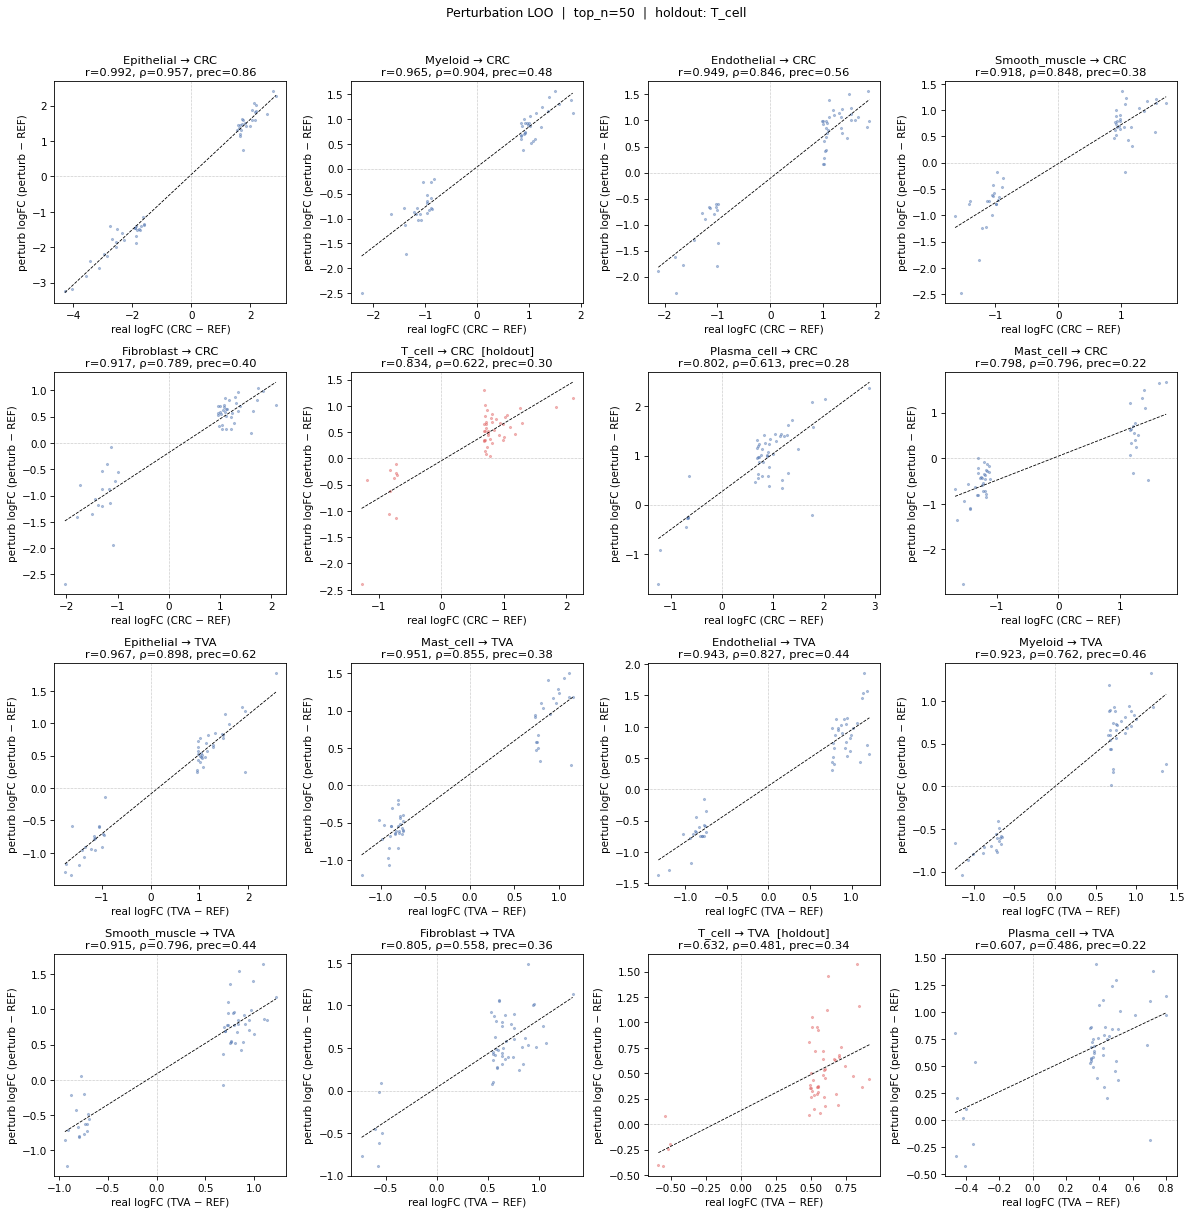

In [23]:
ncols = 4
nrows = (len(summary_df) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
axes = axes.flatten()

for i, row in summary_df.iterrows():
    ct     = row['cell_type']
    target = row['target']
    key    = f"{ct}_{target}"
    ax     = axes[i]
    real = logfcs[key]['real_logfc']
    pred = logfcs[key]['pred_logfc']
    mask = logfcs[key]['top_n_mask']
    if mask is not None:
        real, pred = real[mask], pred[mask]

    color = '#e05c5c' if row['holdout'] else '#4C72B0'
    ax.scatter(real, pred, s=4, alpha=0.4, color=color)

    m, b = np.polyfit(real, pred, 1)
    x_lo, x_hi = real.min(), real.max()
    ax.plot([x_lo, x_hi], [m * x_lo + b, m * x_hi + b], color='k', lw=0.8, ls='--')
    ax.axhline(0, color='grey', lw=0.5, ls=':')
    ax.axvline(0, color='grey', lw=0.5, ls=':')

    title = f"{ct} → {target}{'  [holdout]' if row['holdout'] else ''}"
    ax.set_title(
        f"{title}\nr={row['pearson_r']:.3f}, ρ={row['spearman_r']:.3f}, prec={row['precision']:.2f}",
        fontsize=11,
    )
    ax.set_xlabel(f'real logFC ({target} − REF)', fontsize=10)
    ax.set_ylabel('perturb logFC (perturb − REF)', fontsize=10)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f"Perturbation LOO  |  top_n={top_n}  |  holdout: {holdout_celltype}", y=1.01)
plt.tight_layout()
plt.show()


## 7b. Visualization: Node Perturbation logFC Scatter Plots

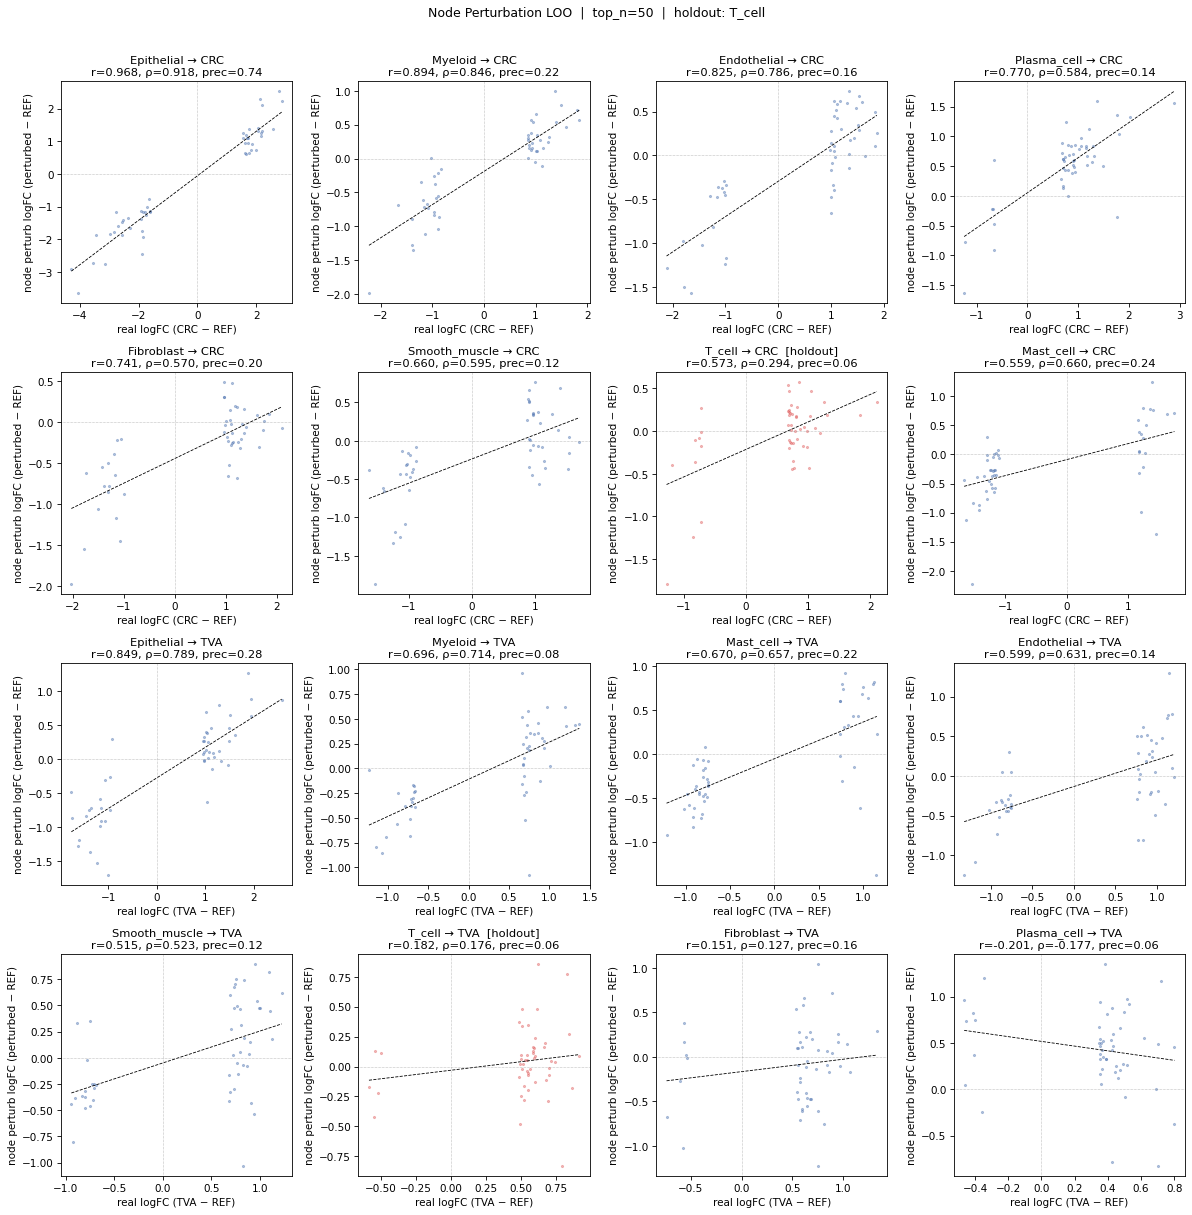

In [24]:
ncols = 4
nrows = (len(node_summary_df) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
axes = axes.flatten()

for i, row in node_summary_df.iterrows():
    ct     = row['cell_type']
    target = row['target']
    key    = f"{ct}_{target}"
    ax     = axes[i]
    real = node_logfcs[key]['real_logfc']
    pred = node_logfcs[key]['pred_logfc']
    mask = node_logfcs[key]['top_n_mask']
    if mask is not None:
        real, pred = real[mask], pred[mask]

    color = '#e05c5c' if row['holdout'] else '#4C72B0'
    ax.scatter(real, pred, s=4, alpha=0.4, color=color)

    m, b = np.polyfit(real, pred, 1)
    x_lo, x_hi = real.min(), real.max()
    ax.plot([x_lo, x_hi], [m * x_lo + b, m * x_hi + b], color='k', lw=0.8, ls='--')
    ax.axhline(0, color='grey', lw=0.5, ls=':')
    ax.axvline(0, color='grey', lw=0.5, ls=':')

    title = f"{ct} \u2192 {target}{'  [holdout]' if row['holdout'] else ''}"
    ax.set_title(
        f"{title}\nr={row['pearson_r']:.3f}, \u03c1={row['spearman_r']:.3f}, prec={row['precision']:.2f}",
        fontsize=11,
    )
    ax.set_xlabel(f'real logFC ({target} \u2212 REF)', fontsize=10)
    ax.set_ylabel('node perturb logFC (perturbed \u2212 REF)', fontsize=10)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f"Node Perturbation LOO  |  top_n={top_n}  |  holdout: {holdout_celltype}", y=1.01)
plt.tight_layout()
plt.show()


In [25]:
model.get_marginal_ll(adata, indices=model.test_indices_, return_mean=True)

/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/scvi/dataloaders/_data_splitting.py:210: UserWarning: Last batch will have a small size of 1samples. Consider changing settings.batch_size or batch_size in model.traincurrently 128 to avoid errors during model training.
  self.n_train, self.n_val = validate_data_split(
/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: The usage of the 'directed' argument in 'NeighborSampler' is deprecated. Use `subgraph_type='induced'` instead.
  neighbor_sampler = NeighborSampler(


-495.0908508300781

In [26]:
import scib_metrics

s = adata.obsm['s']

#subset to 0.2 of cells
rng = np.random.default_rng(seed=42)
idx = rng.choice(s.shape[0], size=int(s.shape[0] * 0.2), replace=False)
s = s[idx]
domain_labels = adata.obs[domains_key].values[idx]

out = scib_metrics.nmi_ari_cluster_labels_kmeans(
    labels=domain_labels,
    X=s,
)


2026-05-02 13:51:01 | [INFO] Unable to initialize backend 'cuda': 
2026-05-02 13:51:01 | [INFO] Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
2026-05-02 13:51:01 | [INFO] Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
2026-05-02 13:51:01 | [WARNING] An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


In [27]:
print(f"ARI (s latent, {domains_key}): {out['ari']:.4f}")

ARI (s latent, typ): 0.7223


In [28]:
print(f"NMI (s latent, {domains_key}): {out['nmi']:.4f}")

NMI (s latent, typ): 0.7544
